# Classificatore Baseline - RAD-DINO (foundation medico) con Fine-Tuning

Equivalente del notebook `13_Classificatore_Baseline_MaxViT512_FineTuned.ipynb` con backbone **RAD-DINO** (Microsoft, ViT-B/14 pre-addestrato su radiografie/mammografie) al posto di MaxViT-Tiny-512 (pre-addestrato ImageNet-1k). Serve a rispondere a una domanda di ricerca aggiuntiva:

> **D2c**: *Un backbone pre-addestrato su dati medici (RAD-DINO) supera MaxViT-Tiny-512 pre-addestrato ImageNet nella baseline sui soli dati reali?*

Configurazione:

- input nativo `518x518` (ViT-B/14 patch 14): le mammografie 512x512 vengono ridimensionate;
- normalizzazione ImageNet RGB con grayscale replicato su 3 canali (coerente con `microsoft/rad-dino`);
- Fase 1: head training, backbone congelato, `BCEWithLogitsLoss` con `pos_weight` bilanciato;
- Fase 2: sblocco degli ultimi 2 block Transformer + LayerNorm finale, `BinaryFocalLoss(α=0.75, γ=2)`, `lr=1e-5`;
- soglia di Youden sul validation set;
- salvataggio di metriche, curve di training e configurazione in `experiments/classifiers/raddino/04a_real_only/`.

Le utility condivise (`fit`, `EarlyStopping`, `ModelCheckpoint`, `CSVLogger`, `BinaryFocalLoss`) provengono da [`maxvit_utils.py`](maxvit_utils.py) e vengono riesportate da [`medfoundation_utils.py`](medfoundation_utils.py).

In [1]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-9a95e5e1-599d-6315-52fb-b6a602960eb8"  # RTX 3060
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

CUDA_VISIBLE_DEVICES: GPU-9a95e5e1-599d-6315-52fb-b6a602960eb8


In [2]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print(tf.config.list_physical_devices("GPU"))

for d in device_lib.list_local_devices():
    if d.device_type == "GPU":
        print(d.physical_device_desc)

2026-07-06 02:38:25.281788: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-06 02:38:25.281819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-06 02:38:25.282754: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-06 02:38:25.287739: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-06 02:38:25.841861: W tensorflow/compiler/tf2

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


2026-07-06 02:38:26.700655: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-06 02:38:26.741225: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-06 02:38:26.744876: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
import sys

# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e' gia' definito dal bootstrap unificato in cima.
print('Percorso base:', BASE_PATH)

Ambiente locale rilevato.
Percorso base: ../


#### Import librerie

In [4]:
import json
import zipfile
from datetime import date

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)

sys.path.insert(0, os.getcwd())
from medfoundation_utils import (
    DEFAULT_MODEL_NAME, DEFAULT_IMAGENET_MEAN, DEFAULT_IMAGENET_STD, DEFAULT_IMG_SIZE,
    build_medfoundation_model, resolve_normalization_medfoundation,
    make_medfoundation_dataloader,
    freeze_backbone_all, unfreeze_head, unfreeze_last_n_blocks,
    count_trainable_params,
    BinaryFocalLoss, compute_pos_weight,
    EarlyStopping, ModelCheckpoint, CSVLogger, fit,
    predict_probs, optimal_threshold_youden,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


#### Verifica presenza dataset preprocessato

In [5]:
PROCESSED_DRIVE_ID = '1qQral_BIBlMl0QN3PllJukdYTOmNGWr3'
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'train.csv')
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'val.csv')


def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False


if not processed_data_ready():
    print('Dataset non trovato, scarico da Google Drive...')
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
else:
    print('Dataset gia\' presente, salto il download')

Dataset gia' presente, salto il download


#### Configurazione esperimento

In [6]:
MODEL_NAME = DEFAULT_MODEL_NAME  # microsoft/rad-dino
IMG_SIZE = DEFAULT_IMG_SIZE      # 518 (ViT-B/14)
BATCH_SIZE = 4                   # 518x518 su ViT-B/14 e' piu' pesante di MaxViT-tiny; ridurre ulteriormente se OOM
SEED = 42

torch.manual_seed(SEED); np.random.seed(SEED)

OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'classifiers/raddino/04a_real_only')
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(OUTPUT_DIR)

../experiments/exp_raddino_baseline


#### Preparazione DataFrame e DataLoader

In [7]:
df_train = pd.read_csv(TRAIN_CSV_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_train['processed_path'] = df_train['processed_path'].apply(fix_path)
df_val['processed_path'] = df_val['processed_path'].apply(fix_path)

print('Costruzione backbone RAD-DINO in corso...')
model, image_processor, hidden_size = build_medfoundation_model(model_name=MODEL_NAME, num_classes=1)
resolved_mean, resolved_std, resolved_size = resolve_normalization_medfoundation(image_processor)
if resolved_size != IMG_SIZE:
    print(f"Attenzione: image_processor dichiara size={resolved_size}, usero' {IMG_SIZE} per compatibilita' con maxvit_utils.fit.")
model.to(DEVICE)

train_loader = make_medfoundation_dataloader(
    df_train, 'processed_path', 'cancer',
    resolved_mean, resolved_std, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=True, augment=False, seed=SEED,
)
val_loader = make_medfoundation_dataloader(
    df_val, 'processed_path', 'cancer',
    resolved_mean, resolved_std, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False,
)

n_pos = int((df_train['cancer'] == 1).sum())
n_neg = int((df_train['cancer'] == 0).sum())
print(f"Train: {len(df_train)} img (cancer=1: {n_pos}, cancer=0: {n_neg}) | Val: {len(df_val)}")
print(f"Backbone hidden_size: {hidden_size}")

Costruzione backbone RAD-DINO in corso...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Train: 2041 img (cancer=1: 340, cancer=0: 1701) | Val: 437
Backbone hidden_size: 768


In [8]:
experiment_config = {
    'experiment_name': os.path.basename(OUTPUT_DIR),
    'date': date.today().isoformat(),
    'backbone': {
        'name': MODEL_NAME,
        'library': 'transformers',
        'pretraining': 'radiographs/mammograms (self-supervised DINOv2)',
        'input_shape': [IMG_SIZE, IMG_SIZE, 3],
        'hidden_size': hidden_size,
    },
    'head': {
        'type': 'Linear on CLS token',
        'dropout': 0.1,
        'output': 'Linear(1) [logits, BCEWithLogitsLoss / BinaryFocalLoss]',
    },
    'preprocessing': {
        'img_size': [IMG_SIZE, IMG_SIZE],
        'normalization': 'ImageNet mean/std (grayscale replicato su 3 canali)',
    },
    'data': {
        'batch_size': BATCH_SIZE, 'seed': SEED, 'augmentation': False,
        'train_csv': TRAIN_CSV_PATH, 'val_csv': VAL_CSV_PATH,
    },
    'phase1_head_training': {
        'optimizer': 'Adam', 'learning_rate': 1e-3,
        'loss': 'BCEWithLogitsLoss(pos_weight=balanced)',
        'max_epochs': 25, 'early_stopping_monitor': 'val_auc',
        'early_stopping_patience': 7, 'backbone_trainable': False,
    },
    'phase2_fine_tuning': {
        'optimizer': 'Adam', 'learning_rate': 1e-5,
        'loss': 'BinaryFocalLoss(alpha=0.75, gamma=2.0)',
        'max_epochs': 30, 'unfreeze': 'ultimi 2 block ViT + layernorm',
        'early_stopping_monitor': 'val_auc',
        'early_stopping_patience': 5, 'early_stopping_min_delta': 1e-3,
        'reduce_lr_factor': 0.5, 'reduce_lr_patience': 3, 'min_lr': 1e-7,
    },
}
with open(os.path.join(OUTPUT_DIR, 'experiment_config.json'), 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print('Configurazione salvata in:', os.path.join(OUTPUT_DIR, 'experiment_config.json'))

Configurazione salvata in: ../experiments/exp_raddino_baseline/experiment_config.json


#### Fase 1 — Head training (backbone congelato)

In [ ]:
freeze_backbone_all(model)
unfreeze_head(model)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 1): {trainable:,} / {total:,}")

pos_weight = compute_pos_weight(df_train['cancer'].values).to(DEVICE)
criterion_fase1 = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_fase1 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-3,
)

early_stop_fase1 = EarlyStopping(patience=7, mode='max', restore_best_weights=True)
checkpoint_fase1 = ModelCheckpoint(os.path.join(OUTPUT_DIR, 'baseline_raddino_fase1_best.pt'), mode='max')
csv_logger_fase1 = CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase1.csv'))

history_phase1 = fit(
    model, train_loader, val_loader, optimizer_fase1, criterion_fase1,
    epochs=25, device=DEVICE,
    early_stopping=early_stop_fase1, checkpoint=checkpoint_fase1, csv_logger=csv_logger_fase1,
)


Parametri trainable (Fase 1): 769 / 86,581,249
Epoch 1/25 - loss: 1.1849 - auc: 0.5350 - val_loss: 1.1946 - val_auc: 0.5470
Epoch 2/25 - loss: 1.1477 - auc: 0.5877 - val_loss: 1.1485 - val_auc: 0.5986
Epoch 3/25 - loss: 1.1149 - auc: 0.6198 - val_loss: 1.1545 - val_auc: 0.5768
Epoch 4/25 - loss: 1.1062 - auc: 0.6338 - val_loss: 1.2496 - val_auc: 0.5831
Epoch 5/25 - loss: 1.1054 - auc: 0.6353 - val_loss: 1.1540 - val_auc: 0.6038
Epoch 6/25 - loss: 1.0773 - auc: 0.6696 - val_loss: 1.1692 - val_auc: 0.6096
Epoch 7/25 - loss: 1.0784 - auc: 0.6725 - val_loss: 1.1993 - val_auc: 0.5982
Epoch 8/25 - loss: 1.0556 - auc: 0.6880 - val_loss: 1.1719 - val_auc: 0.6074
Epoch 9/25 - loss: 1.0475 - auc: 0.6985 - val_loss: 1.2870 - val_auc: 0.6059
Epoch 10/25 - loss: 1.0386 - auc: 0.7039 - val_loss: 1.1811 - val_auc: 0.6269
Epoch 11/25 - loss: 1.0418 - auc: 0.7037 - val_loss: 1.1990 - val_auc: 0.6185
Epoch 12/25 - loss: 1.0453 - auc: 0.7004 - val_loss: 1.2019 - val_auc: 0.5971
Epoch 13/25 - loss: 1.0347

#### Fase 2 — Sblocco parziale del backbone (ultimi 2 block + layernorm)

In [10]:
unfreeze_last_n_blocks(model, n=2)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 2): {trainable:,} / {total:,}")

criterion_fase2 = BinaryFocalLoss(alpha=0.75, gamma=2.0)
optimizer_fase2 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-5,
)
lr_scheduler_fase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase2, mode='max', factor=0.5, patience=3, min_lr=1e-7,
)
early_stop_fase2 = EarlyStopping(patience=5, min_delta=1e-3, mode='max', restore_best_weights=True)
checkpoint_fase2 = ModelCheckpoint(os.path.join(OUTPUT_DIR, 'baseline_raddino_final_best.pt'), mode='max')
csv_logger_fase2 = CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase2.csv'))

history_phase2 = fit(
    model, train_loader, val_loader, optimizer_fase2, criterion_fase2,
    epochs=30, device=DEVICE,
    early_stopping=early_stop_fase2, checkpoint=checkpoint_fase2, csv_logger=csv_logger_fase2,
    lr_scheduler=lr_scheduler_fase2,
)
print('\nTraining completato. Best model:', os.path.join(OUTPUT_DIR, 'baseline_raddino_final_best.pt'))

Parametri trainable (Fase 2): 14,181,121 / 86,581,249
Epoch 1/30 - loss: 0.0528 - auc: 0.7211 - val_loss: 0.0646 - val_auc: 0.6307
Epoch 2/30 - loss: 0.0462 - auc: 0.7801 - val_loss: 0.0625 - val_auc: 0.6196
Epoch 3/30 - loss: 0.0451 - auc: 0.7889 - val_loss: 0.0670 - val_auc: 0.6226
Epoch 4/30 - loss: 0.0419 - auc: 0.8246 - val_loss: 0.0620 - val_auc: 0.6412
Epoch 5/30 - loss: 0.0387 - auc: 0.8589 - val_loss: 0.0677 - val_auc: 0.6278
Epoch 6/30 - loss: 0.0337 - auc: 0.9022 - val_loss: 0.0815 - val_auc: 0.6171
Epoch 7/30 - loss: 0.0291 - auc: 0.9288 - val_loss: 0.0866 - val_auc: 0.6122
Epoch 8/30 - loss: 0.0217 - auc: 0.9653 - val_loss: 0.1130 - val_auc: 0.6167
Epoch 9/30 - loss: 0.0146 - auc: 0.9878 - val_loss: 0.1162 - val_auc: 0.6219
Early stopping all'epoca 9 (best val_auc=0.6412)

Training completato. Best model: ../experiments/exp_raddino_baseline/baseline_raddino_final_best.pt


#### Curve di training

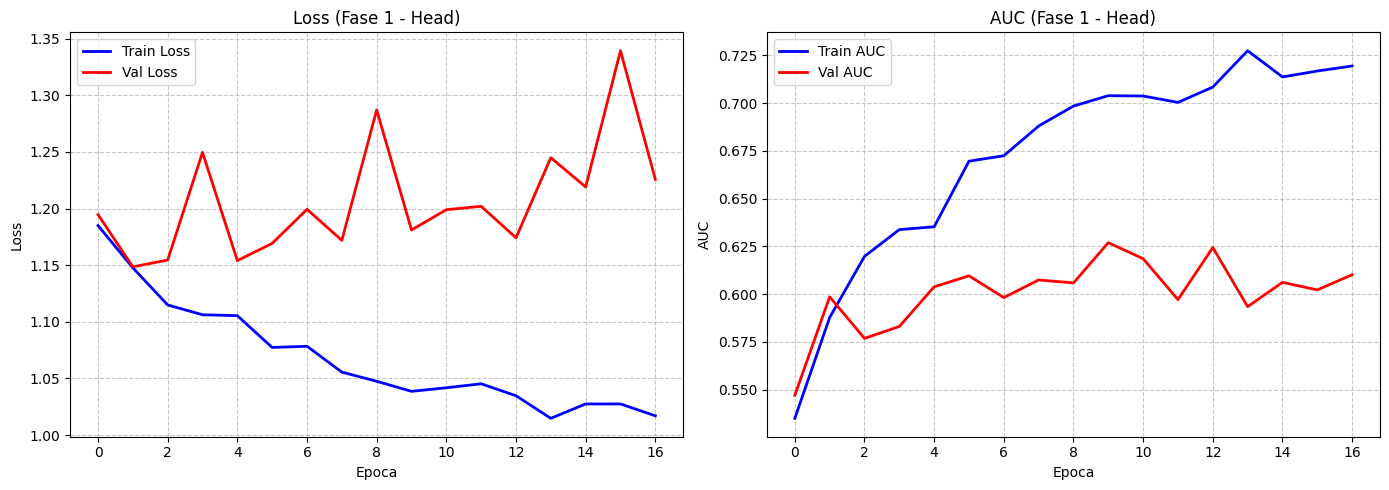

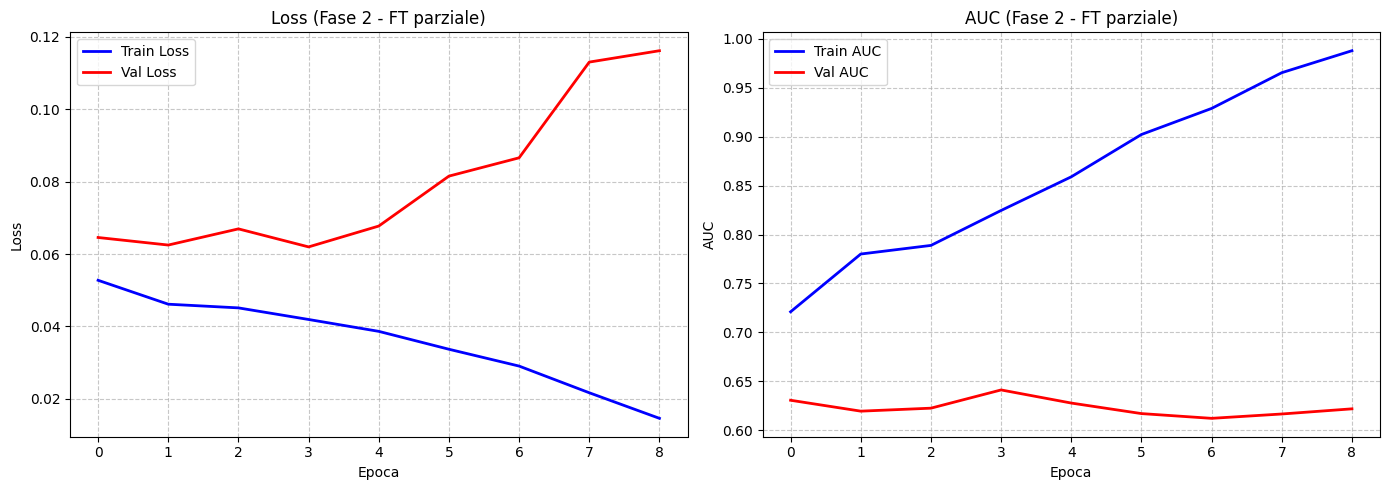

In [11]:
def plot_training_history(history, title_suffix='', save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set(title=f'Loss {title_suffix}', xlabel='Epoca', ylabel='Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.7)
    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set(title=f'AUC {title_suffix}', xlabel='Epoca', ylabel='AUC')
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_phase1, '(Fase 1 - Head)', save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png'))
plot_training_history(history_phase2, '(Fase 2 - FT parziale)', save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png'))

#### Valutazione sul validation set con soglia di Youden

AUC: 0.6412
Soglia ottimale: 0.457

              precision    recall  f1-score   support

   No cancro       0.90      0.63      0.74       364
      Cancro       0.26      0.66      0.38        73

    accuracy                           0.63       437
   macro avg       0.58      0.64      0.56       437
weighted avg       0.79      0.63      0.68       437



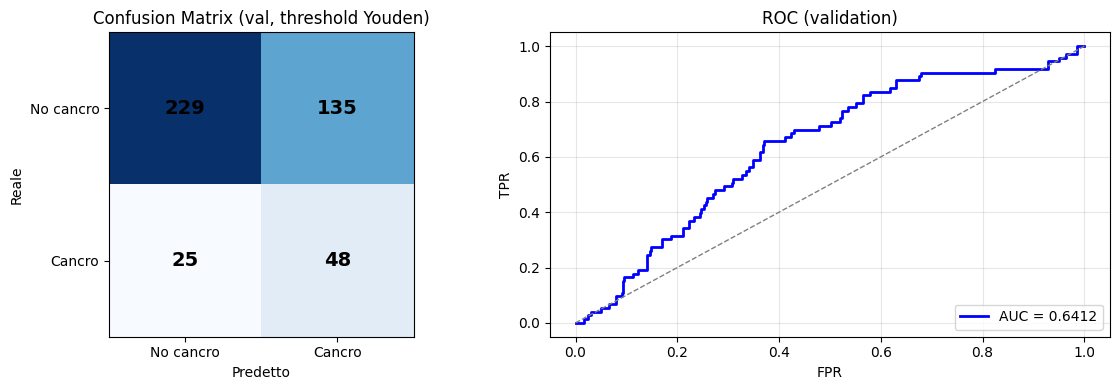

Metriche salvate in: ../experiments/exp_raddino_baseline/val_metrics.json


In [12]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'baseline_raddino_final_best.pt'), map_location=DEVICE))
y_true, y_pred_prob = predict_probs(model, val_loader, DEVICE)
best_threshold = optimal_threshold_youden(y_true, y_pred_prob)
y_pred = (y_pred_prob >= best_threshold).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])
print(f'AUC: {val_auc:.4f}\nSoglia ottimale: {best_threshold:.3f}\n')
print(report_str)

metrics_dict = {
    'split': 'validation',
    'backbone': MODEL_NAME,
    'experiment_name': os.path.basename(OUTPUT_DIR),
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
with open(os.path.join(OUTPUT_DIR, 'val_metrics.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix (val, threshold Youden)')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC (validation)')
axes[1].legend(loc='lower right'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'val_confusion_roc.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Metriche salvate in:', os.path.join(OUTPUT_DIR, 'val_metrics.json'))